# **Exploratory Data Analysis (EDA)** 
Basado en la información del dataset ***Bank Marketing*** en la url = "https://archive.ics.uci.edu/dataset/222/bank+marketing"

**Objetivos:**
Facilitar una comprensión inicial del dataset.
- Presentación de resúmenes estadísticos descriptivos (media, mediana, moda, desviación estándar, etc.)
- Crear visualizaciones iniciales (histogramas, gráficos de dispersión, boxplot, etc.) para identificar tendencias o anomalías. 
- Detectar correlaciones entre variables. 

### Importación de bibliotecas

In [15]:
import mysql.connector
from mysql.connector import Error

import pandas as pd

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#%pip install ydata-profiling
from ydata_profiling import ProfileReport

%matplotlib inline


### Conectando al servidor

In [4]:

user_db = 'Equipo23'
password_db = 'E1q2u3i4p5o23'
host_db = '212.227.90.6'
database_name = 'Equip_23'


try:
    conexion = mysql.connector.connect(
        user=user_db,
        password=password_db,
        host=host_db,
        database=database_name,
        
    )
    print("¡Conexión a MySQL establecida con éxito!")

except Exception as e:
    print(f"Error al conectar a MySQL: {e}")



¡Conexión a MySQL establecida con éxito!


### Cargando el dataset

In [5]:

query = "SELECT * FROM BANK_marketing;"              
df_bank = pd.read_sql(query, conexion)


C:\Users\usuario\AppData\Local\Temp\ipykernel_15668\2735028799.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bank = pd.read_sql(query, conexion)


### Información general del dataset

In [6]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  object 
 3   marital    10637 non-null  object 
 4   education  10635 non-null  object 
 5   default    10642 non-null  object 
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  object 
 8   loan       10642 non-null  object 
 9   contact    10642 non-null  object 
 10  day        10642 non-null  int64  
 11  month      10642 non-null  object 
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  object 
 17  deposit    10642 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 1.5+ MB


En el dataset se observan dos tipos de variables: numéricas y categóricas. 
Los tipos de datos parecen bien categorizados en general. 
Por ejemplo, variables como age, balance, y duration están correctamente clasificadas como numéricas (float64 o int64), mientras que variables como job, marital, education, y deposit están definidas como categóricas (object). 

### Descripción estadística para variables numéricas 

In [7]:
# Seleccionamos columnas numericas
numerical_columns = df_bank.select_dtypes(include=[np.number])

# Calcula estadísticas descriptivas básicas y voltea la tabla
numerical_stats = numerical_columns.describe().transpose()

# Calcula la moda
numerical_mode = numerical_columns.mode().iloc[0]

# Añade la moda y la mediana a la tabla de las estadísticas descriptivas
numerical_stats['mode'] = numerical_mode
numerical_stats['median'] = numerical_columns.median()

# Enseña las estadísticas elegidas en una tabla
numerical_stats[['mean', 'median', 'mode', 'std']].round(2)

,mean,median,mode,std
id,5321.50,5321.5,1.0,3072.23
age,41.25,39.0,31.0,12.00
balance,1536.61,558.0,0.0,3223.42
day,15.65,15.0,20.0,8.43
duration,378.69,260.0,97.0,351.18
campaign,2.50,2.0,1.0,2.69
pdays,52.07,-1.0,-1.0,109.21
previous,0.85,0.0,0.0,2.32


### EDA automático con Ydata
Un EDA automático para ver de antemano qué son los gráficos importantes y las variables a destacar.

In [ ]:
# EDA automático con ydata‑profiling


profile = ProfileReport(df_bank, title="EDA automàtic")
profile.to_file("EDA_report.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 33.31it/s]


In [9]:
# Histograma de cada variable numèrica
df_bank.hist(bins=30, figsize=(15, 10))
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_15668\3667218954.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Visualizaciones segun el tipo de variable

Creando: id_histograma.png


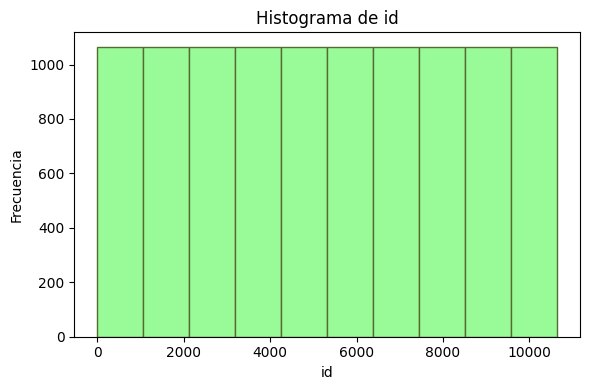

Creando: age_histograma.png


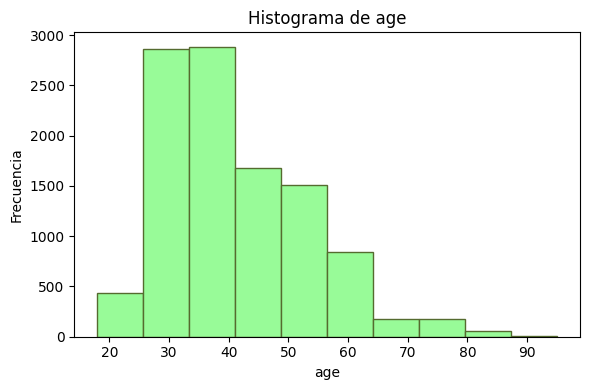

Creando: job_barras.png


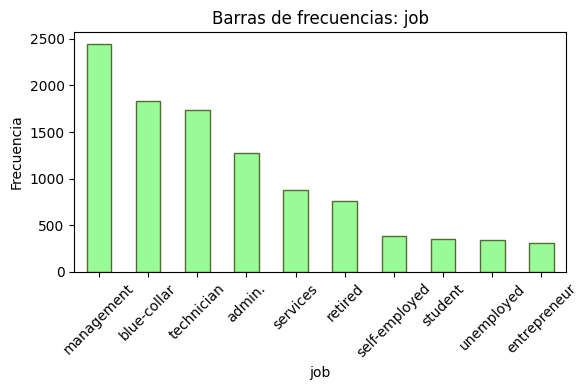

Creando: marital_barras.png


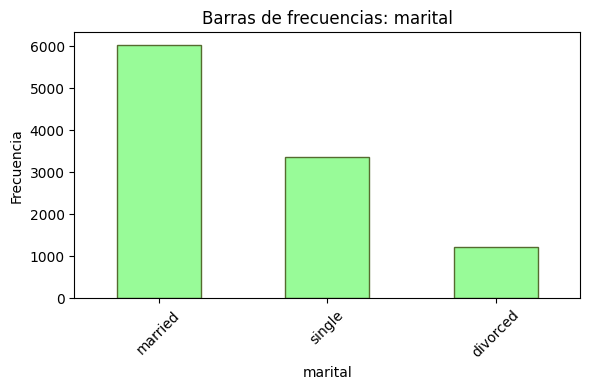

Creando: education_barras.png


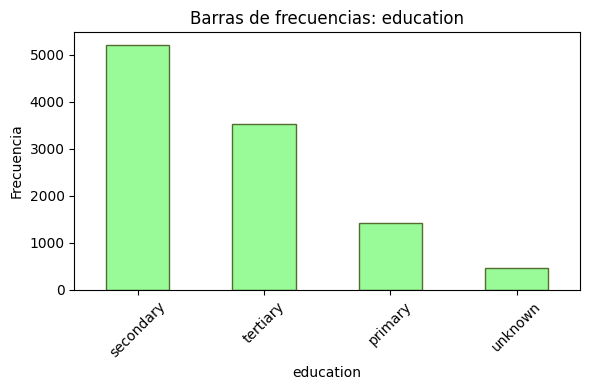

Creando: default_barras.png


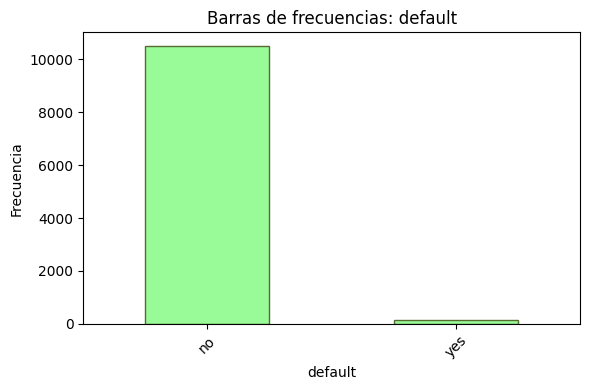

Creando: balance_histograma.png


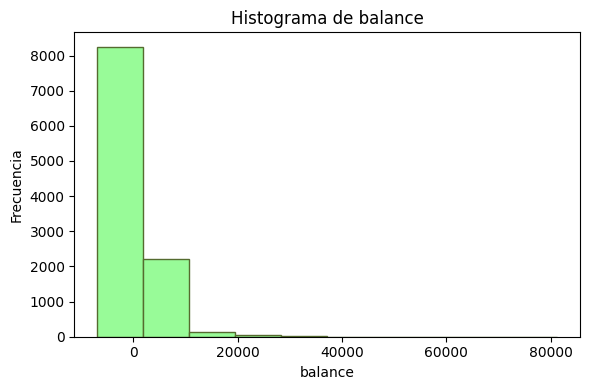

Creando: housing_barras.png


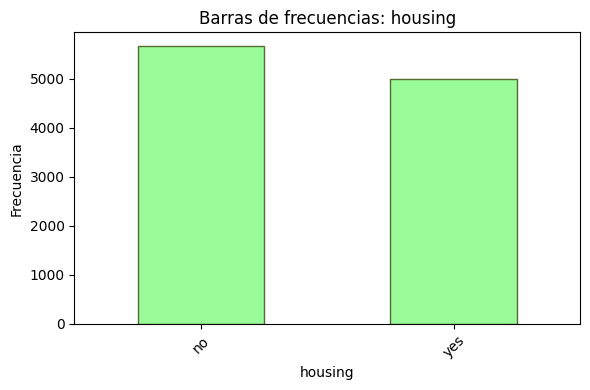

Creando: loan_barras.png


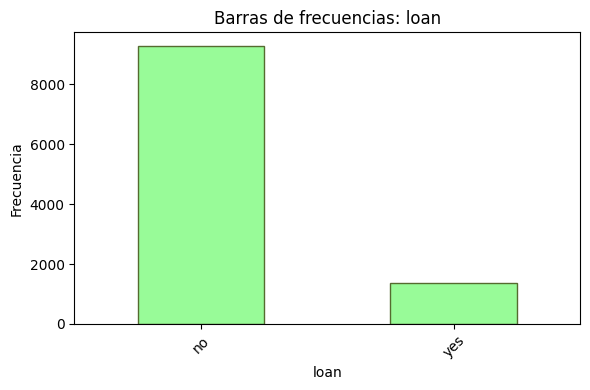

Creando: contact_barras.png


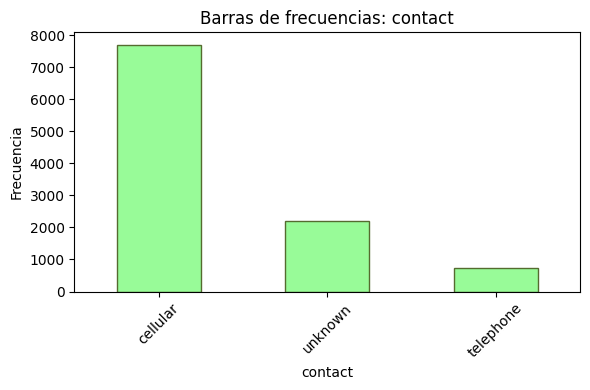

Creando: day_histograma.png


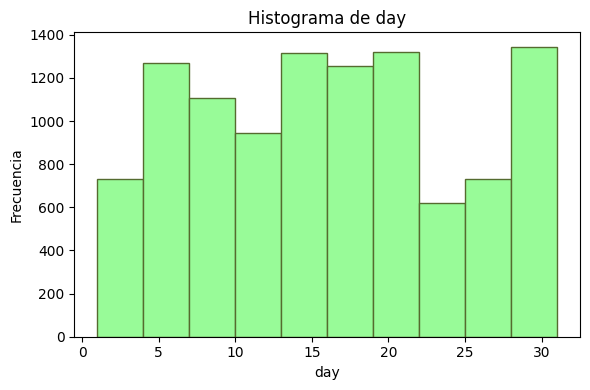

Creando: month_barras.png


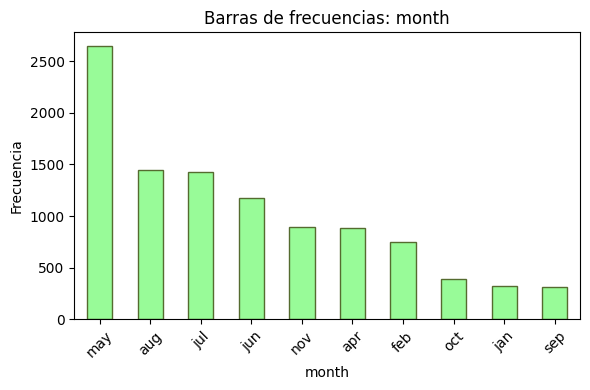

Creando: duration_histograma.png


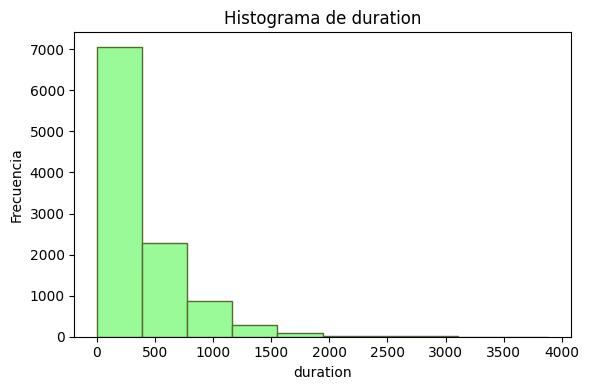

Creando: campaign_histograma.png


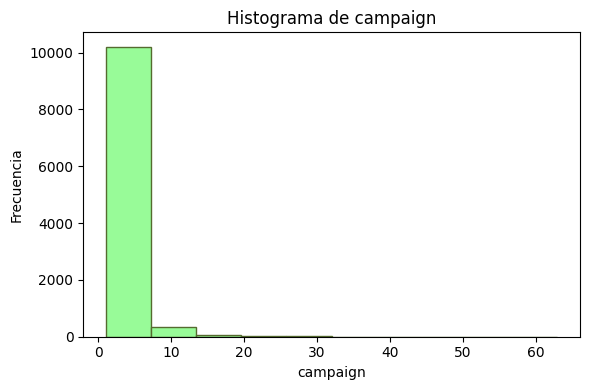

Creando: pdays_histograma.png


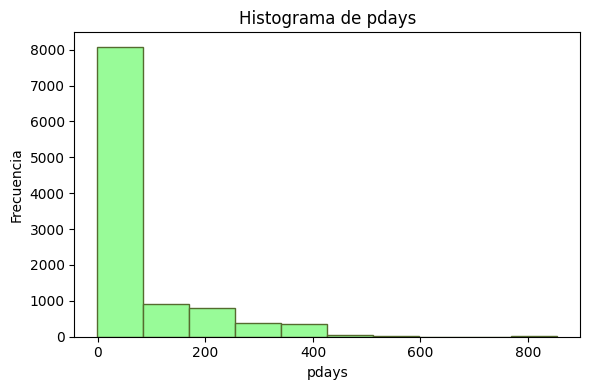

Creando: previous_histograma.png


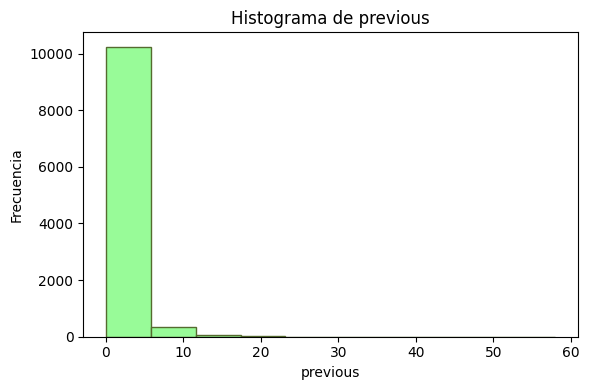

Creando: poutcome_barras.png


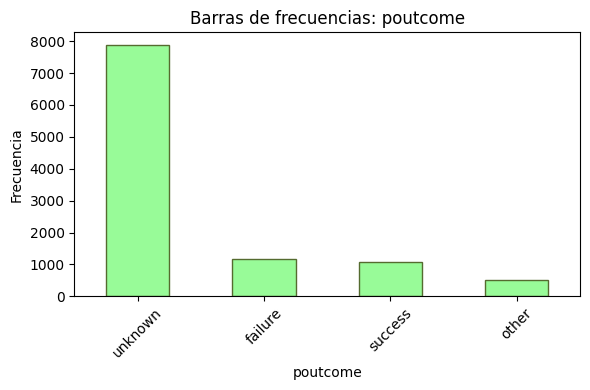

Creando: deposit_barras.png


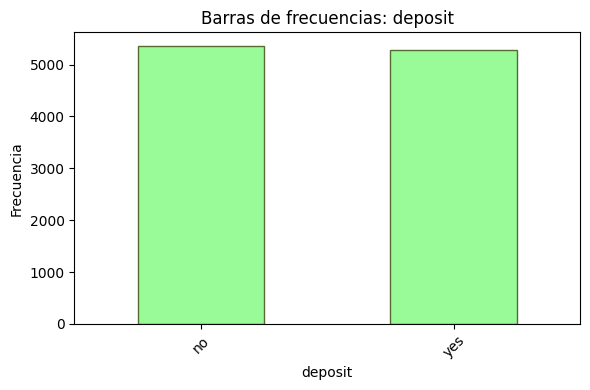

In [17]:


def autografic_df(df):
    """Genera y guarda un gráfico por cada columna del DataFrame"""
    
    os.makedirs("graficos", exist_ok=True)

    for col in df.columns:
        serie = df[col].dropna()
        
        # Si la columna es numérica genera un histograma
        if pd.api.types.is_numeric_dtype(serie) and not pd.api.types.is_bool_dtype(serie):  # filtrar columnas que son numéricas reales, excluyendo las que son booleanas (1, 0)
            plt.figure(figsize=(6, 4))                                                      # marca el tamaño en pulgadas
            plt.hist(serie, bins=10,                                                        # genera un histograma: agrupa los valores en intervalos y cuenta cuántos hay en cada uno.
                     color="palegreen", edgecolor="darkolivegreen")                         # da color al relleno y al borde
            plt.title(f"Histograma de {col}")                                               # le da titulo al gráfico
            plt.xlabel(col)                                                                 # nombre eje X e Y
            plt.ylabel("Frecuencia")
            plt.tight_layout()                                                              # Ajusta los márgenes automáticamente para que todo encaje bien.
            print(f"Creando: {col}_histograma.png")                                        # mensaje de afirmación
            plt.show()                                                                     # se cierra el proceso

                                                                            
        # Si la columna es datetime genera un gráfico de barras
        elif pd.api.types.is_datetime64_any_dtype(serie):                                   # filtrar columnas que son date time
            plt.figure(figsize=(6, 4))
            años = serie.dt.year.value_counts().sort_index()                                # serie.dt.year - Extrae el año de cada fecha en la Serie y .value_counts() cuenta cuantas veces aparece y los ordena por index
            años.plot(kind="bar", color="palegreen", edgecolor="darkolivegreen")            # kind = bar genera un grafico de barras simple
            plt.title(f"Años más frecuentes: {col}")
            plt.xlabel("Año")
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            print(f"Creando: {col}_años.png")
            plt.show()

        # si es bool genera un gráfico de barras
        elif pd.api.types.is_bool_dtype(serie):
            plt.figure(figsize=(4, 4))
            serie.value_counts().plot(kind="bar", color="palegreen", edgecolor="darkolivegreen")
            plt.title(f"Frecuencia booleana: {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=0)
            plt.tight_layout()
            print(f"Creando: {col}_bool.png")
            plt.show()

        # para lo demás (categóricas o numéricas) genera un gráfico de barras con los 10 valores mas comunes
        else:
            plt.figure(figsize=(6, 4))
            serie.value_counts().head(10).plot(kind="bar", color="palegreen", edgecolor="darkolivegreen")
            plt.title(f"Barras de frecuencias: {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            print(f"Creando: {col}_barras.png")
            plt.show()

df= df_bank 

autografic_df(df)

**Observaciones de las variables numéricas**

- **Age**: La mayoría de los clientes tienen entre 20 y 60 años, y de ellos, el mayor número entre los 30 y 40 años de edad. 

- **Balance** no son demasiado altos, hablamos de entre 0 y unos cientos de euros, o como mucho, unos miles. Es posible que este factor varie mucho dependiendo del día del mes. 

- **duration**: vemos que la mayoría de llamadas se terminan rápido

- **campaign**: la gran mayoría fueron contactados menos de 3 veces durante esta campaña, y a algunos pocos más de 5 veces. 

- **pdays**: La mayoría de clientes nunca han sido contactados. Los demás fueron contactados con 100, 200 días antes. 

- **previous**: La gran mayoría de los clientes no fueron contactados en campañas previas.

**Observaciones de las variables categóricas**

- **Sociológico**: La mayoría trabaja de management, está casada y tiene un nivel de educación entre secundario y universitario

- **Housing y Loan**: La mayoría no tiene un prestamo ni hipoteca

- **valores a explorar más** Las categorías como poutcome o contact tienen muchos valores de unknown habría que tratarlo con cuidado e intentar recabar esos datos.


### Detectando correlaciones

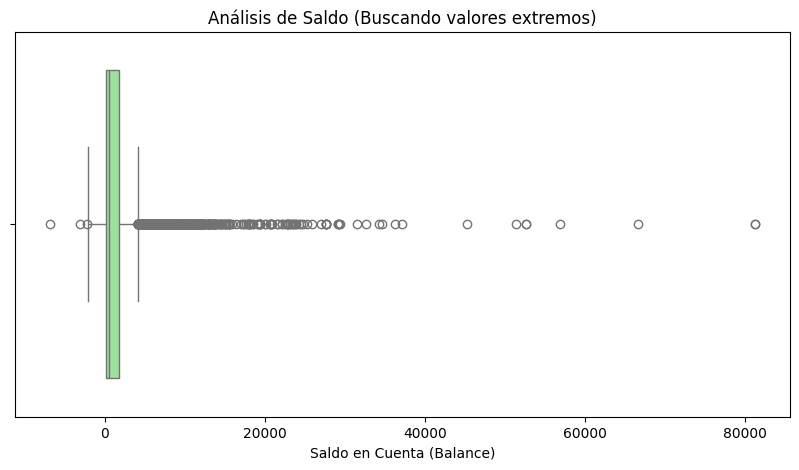

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['balance'], color='lightgreen')
plt.title('Análisis de Saldo (Buscando valores extremos)')
plt.xlabel('Saldo en Cuenta (Balance)')
plt.show()

Balance tiene muchos valores extremos altos, una distribución muy sesgada y una mediana muy baja.

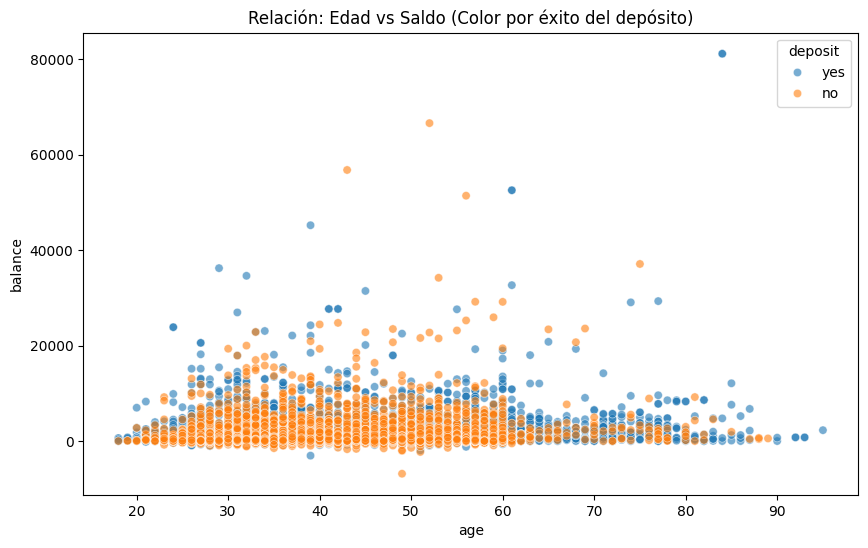

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='balance', hue='deposit', alpha=0.6)
plt.title('Relación: Edad vs Saldo (Color por éxito del depósito)')
plt.show()

No existe relación clara entre edad y saldo, y el depósito no depende estas variables.

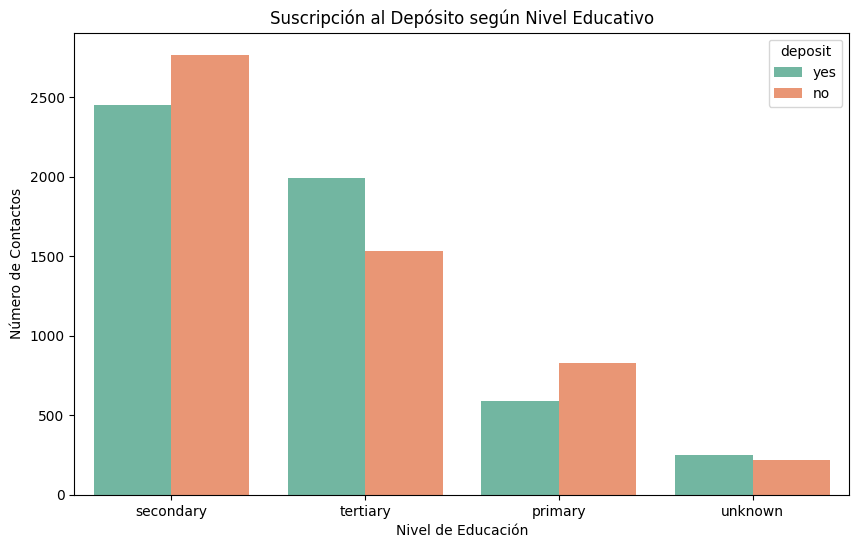

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='deposit', palette='Set2')
plt.title('Suscripción al Depósito según Nivel Educativo')
plt.xlabel('Nivel de Educación')
plt.ylabel('Número de Contactos')
plt.show()

Las personas con estudios primarios y secundarios abren menos depositos pero esto cambia cuando van a la universidad

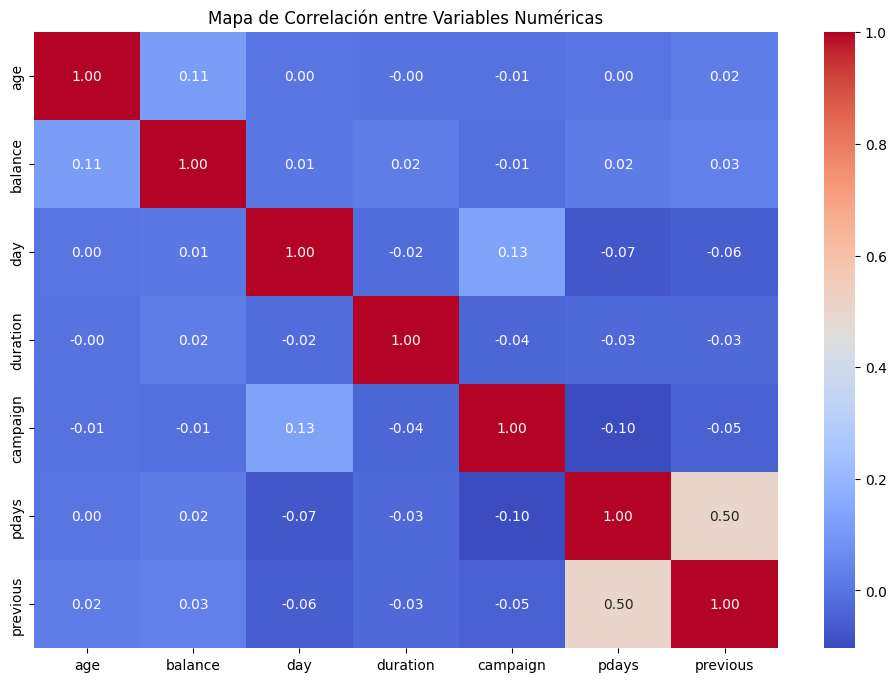

In [27]:
plt.figure(figsize=(12, 8))
# Seleccionamos solo las columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'])
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación entre Variables Numéricas')
plt.show()

Lo único interesante que vemos aquí es que todas las variables están muy poco relacionadas salvo pdays y previous, que indica que cuanto más tiempo haya pasado desde la última llamada, más posibilidades hay de que te llamen. 